In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
from pipeline_draft import Pipeline
import numpy as np 

/Users/cameronkruger/hypo_free_geometry_recovery/hypo311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Sorted by longitude
states_prompts = [
    'Hawaii', 'Alaska', 'Washington', 'Oregon', 'California', 'Nevada', 'Idaho', 'Arizona', 'Utah', 'Montana', 'Wyoming',
    'New Mexico', 'Colorado', 'North Dakota', 'South Dakota', 'Nebraska', 'Texas', 'Kansas', 'Oklahoma', 'Minnesota',
    'Iowa', 'Missouri', 'Arkansas', 'Louisiana', 'Mississippi', 'Wisconsin', 'Illinois', 'Alabama', 'Tennessee', 'Indiana',
    'Michigan', 'Kentucky', 'Georgia', 'Ohio', 'Florida', 'South Carolina', 'West Virginia', 'North Carolina', 'Virginia',
    'Pennsylvania', 'Maryland', 'Delaware', 'New York', 'New Jersey', 'Connecticut', 'Vermont', 'Massachusetts', 'New Hampshire',
    'Rhode Island', 'Maine'
]


states_contextualized_prompts = [f"The location of the US state {st}" for st in states_prompts]

months_prompts = ["January", "February","March","April","May","June","July","August","September","October","November","December"]
months_contextualized_prompts = [f"The month of the year is {s}" for s in months_prompts]

years_prompts = [str(i) for i in range(1700, 2022)]
years_contextualized_prompts = [f"In the year {s}" for s in years_prompts]

In [4]:
months = Pipeline('gemma-2-2b', months_contextualized_prompts)


Loading weights: 100%|██████████| 288/288 [00:00<00:00, 24894.06it/s]


Loaded pretrained model gemma-2-2b into HookedTransformer


In [6]:
best_layer, activations, scores = months.select_layer_by_topology()

Intrinsic dimension (TwoNN): 9.50
PCA: keeping m=10 components (95% variance)
Intrinsic dimension (TwoNN): 8.09
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 7.82
PCA: keeping m=6 components (95% variance)
Intrinsic dimension (TwoNN): 5.08
PCA: keeping m=8 components (95% variance)
Intrinsic dimension (TwoNN): 5.49
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 3.96
PCA: keeping m=6 components (95% variance)
Intrinsic dimension (TwoNN): 11.65
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 7.30
PCA: keeping m=6 components (95% variance)
Intrinsic dimension (TwoNN): 5.26
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 4.13
PCA: keeping m=6 components (95% variance)
Intrinsic dimension (TwoNN): 5.76
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 6.60
PCA: keeping m=7 components (95% variance)
Intrinsic dimension (TwoNN): 9.89
PCA: keeping m=7 components (95% varianc

KeyboardInterrupt: 

In [38]:
baseline_months = np.load('months_contextualized_reps_by_layer.npy',allow_pickle=True).tolist()
baseline_acts = baseline_months['layer_9']

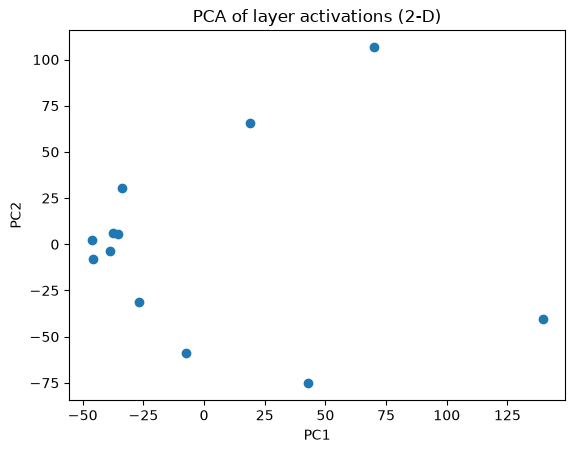

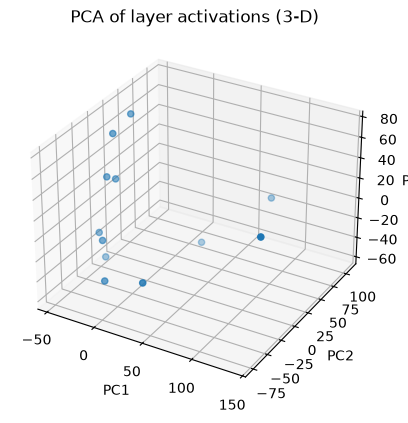

array([[-45.626217 ,  -8.069252 , -27.014399 ],
       [-46.267693 ,   2.4868524, -57.593834 ],
       [ 18.960459 ,  65.90297  , -55.98769  ],
       [ 69.9679   , 106.712395 , -16.110937 ],
       [139.48582  , -40.687798 ,  37.41386  ],
       [ 43.03668  , -75.16264  , -16.987158 ],
       [ -7.281845 , -58.619793 , -38.881203 ],
       [-26.81498  , -31.06955  , -18.154255 ],
       [-35.329887 ,   5.5531864,  22.932957 ],
       [-33.933846 ,  30.569536 ,  75.53939  ],
       [-37.549046 ,   6.109059 ,  66.4222   ],
       [-38.647343 ,  -3.7248333,  28.42121  ]], dtype=float32)

In [37]:
months.plot_pca(activations)

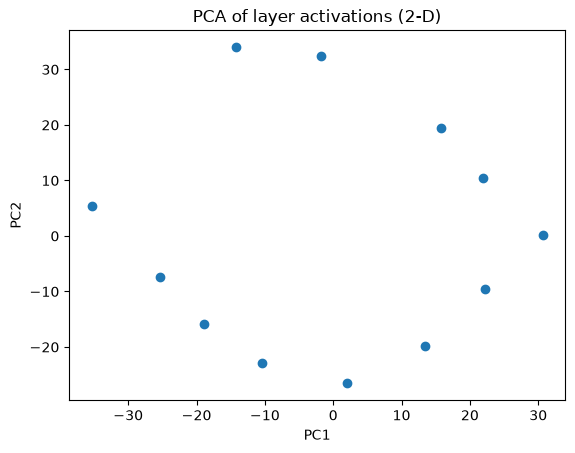

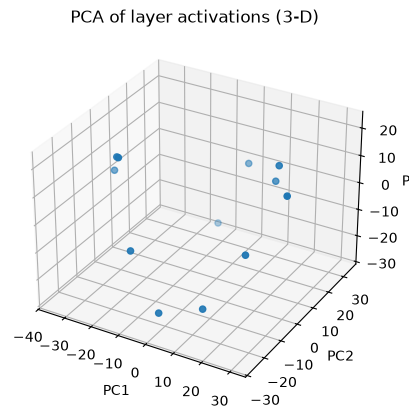

array([[-1.4250600e+01,  3.4013939e+01, -2.7308481e+01],
       [-1.7942275e+00,  3.2402645e+01,  3.4562148e-02],
       [ 1.5709788e+01,  1.9448238e+01,  5.0632148e+00],
       [ 2.1949284e+01,  1.0375922e+01,  1.7152292e+01],
       [ 3.0640741e+01,  2.6318109e-01,  1.4155639e+01],
       [ 2.2216059e+01, -9.5145884e+00, -3.9537585e+00],
       [ 1.3497774e+01, -1.9800928e+01, -2.0276772e+01],
       [ 2.0182619e+00, -2.6513821e+01, -2.1353666e+01],
       [-1.0380428e+01, -2.2803505e+01, -4.6977639e+00],
       [-1.8893570e+01, -1.5865618e+01,  2.2376516e+01],
       [-2.5381027e+01, -7.4012494e+00,  1.6511295e+01],
       [-3.5331970e+01,  5.3957248e+00,  2.2969370e+00]], dtype=float32)

In [39]:
months.plot_pca(baseline_acts)